In [11]:
import pandas as pd 
import numpy as np 

df = pd.read_csv('salary_prediction_data.csv')
df.shape
df.isnull().sum()
df.info()

df.head(5)
df.duplicated().sum()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Education   1000 non-null   object 
 1   Experience  1000 non-null   int64  
 2   Location    1000 non-null   object 
 3   Job_Title   1000 non-null   object 
 4   Age         1000 non-null   int64  
 5   Gender      1000 non-null   object 
 6   Salary      1000 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


,Education,Experience,Location,Job_Title,Age,Gender,Salary
0,High School,8,Urban,Manager,63,Male,84620.053665
1,PhD,11,Suburban,Director,59,Male,142591.255894
2,Bachelor,28,Suburban,Manager,61,Female,97800.255404
3,High School,29,Rural,Director,45,Male,96834.671282
4,PhD,25,Urban,Analyst,26,Female,132157.786175


In [38]:
#encoding caterigal columns 
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder

le = LabelEncoder()
df['Gender']    = le.fit_transform(df['Gender'])   
df['Education'] = le.fit_transform(df['Education'])

#df = pd.get_dummies(df, columns=['Location', 'Job_Title'])

df.head(10)

,Education,Experience,Age,Gender,Salary,gender,Location_Rural,Location_Suburban,Location_Urban,Job_Title_Analyst,Job_Title_Director,Job_Title_Engineer,Job_Title_Manager
0,1,8,63,1,84620.053665,1,False,False,True,False,False,False,True
1,3,11,59,1,142591.255894,1,False,True,False,False,True,False,False
2,0,28,61,0,97800.255404,0,False,True,False,False,False,False,True
3,1,29,45,1,96834.671282,1,True,False,False,False,True,False,False
4,3,25,26,0,132157.786175,0,False,False,True,True,False,False,False
5,3,19,27,0,156312.936208,0,True,False,False,False,True,False,False
6,3,4,60,0,130567.649455,0,True,False,False,False,True,False,False
7,3,13,49,0,148707.740759,0,False,True,False,False,True,False,False
8,0,20,25,0,95945.275429,0,False,False,True,False,False,True,False
9,3,14,58,0,133339.389682,0,False,False,True,True,False,False,False


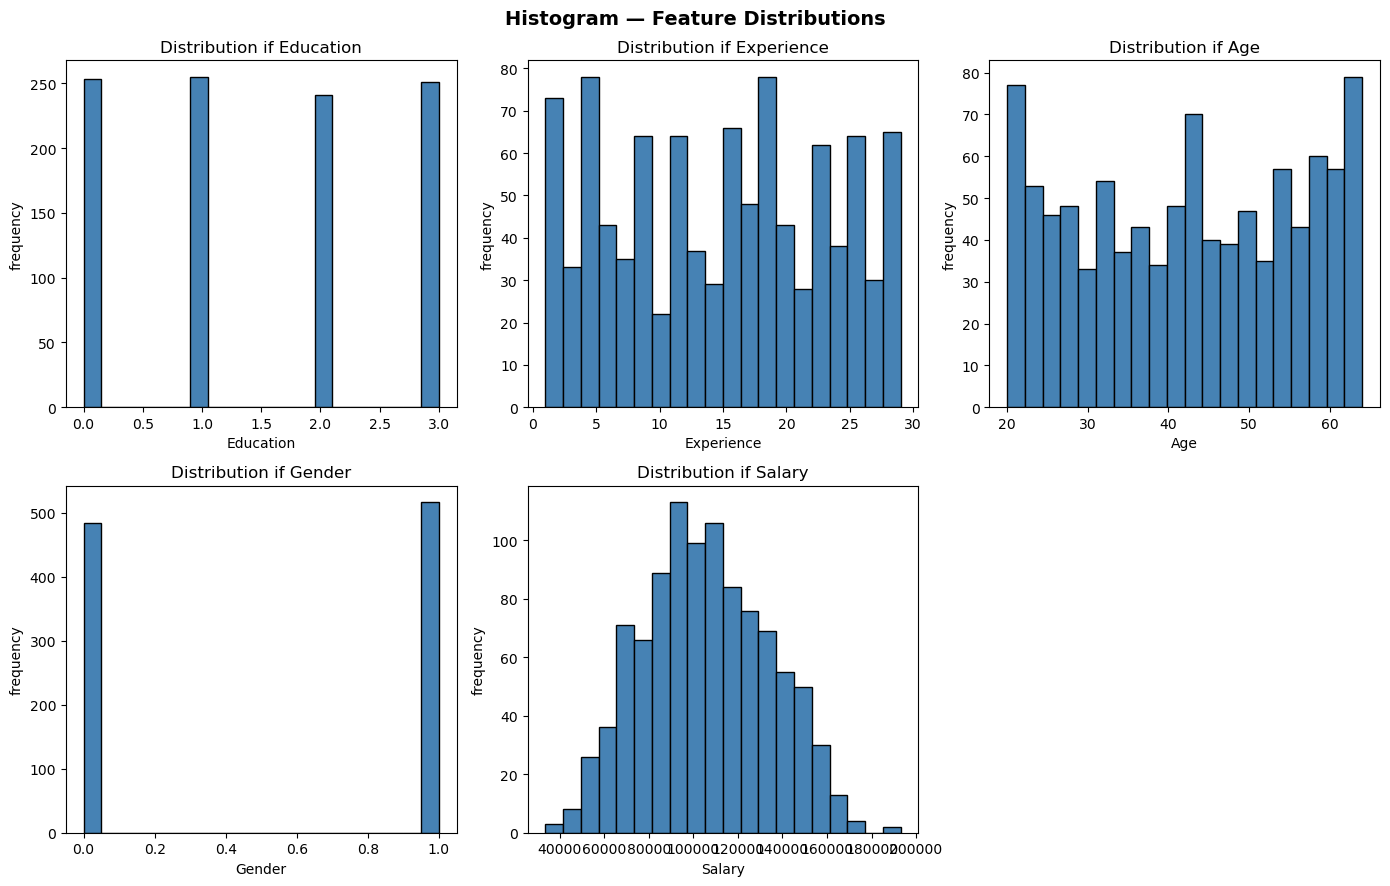

In [42]:
#histogram 
import matplotlib.pyplot as plt
plt.figure(figsize = (14,9))

cols = ['Education' , 'Experience' , 'Age' , 'Gender' , 'Salary']
for i , col in enumerate(cols , 1):
    plt.subplot(2,3,i)
    plt.hist(df[col] , bins = 20 , color='steelblue' , edgecolor = 'black')
    plt.title(f"Distribution if {col}")
    plt.xlabel(col)
    plt.ylabel('frequency')
plt.suptitle('Histogram — Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


/var/folders/pn/4vlx6yks3p12942dzwsq3nv80000gn/T/ipykernel_15848/1807652825.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='Salary', data=df_orig,


([0, 1, 2, 3],
 [Text(0, 0, 'High School'),
  Text(1, 0, 'Bachelor'),
  Text(2, 0, 'Master'),
  Text(3, 0, 'PhD')])

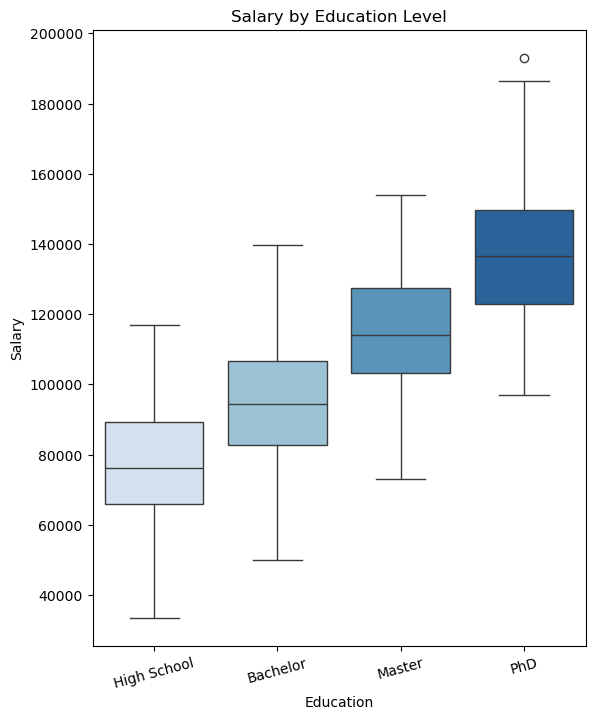

In [48]:
#box-plot 
# salary vs edu
import seaborn as sns
plt.figure(figsize = (14,8))
plt.subplot(1,2,1)
df_orig = pd.read_csv('salary_prediction_data.csv')
sns.boxplot(x='Education', y='Salary', data=df_orig,
            order=['High School', 'Bachelor', 'Master', 'PhD'],
            palette='Blues')
plt.title('Salary by Education Level')
plt.xlabel('Education')
plt.ylabel('Salary')
plt.xticks(rotation=15)



/var/folders/pn/4vlx6yks3p12942dzwsq3nv80000gn/T/ipykernel_15848/879139305.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education', y='Salary', data=df_orig,
/var/folders/pn/4vlx6yks3p12942dzwsq3nv80000gn/T/ipykernel_15848/879139305.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y='Salary', data=df_orig, palette='Set2')
/var/folders/pn/4vlx6yks3p12942dzwsq3nv80000gn/T/ipykernel_15848/879139305.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Job_Title', y='Salary', data=df_orig,
/var/folders/pn/4vlx6yks3p12

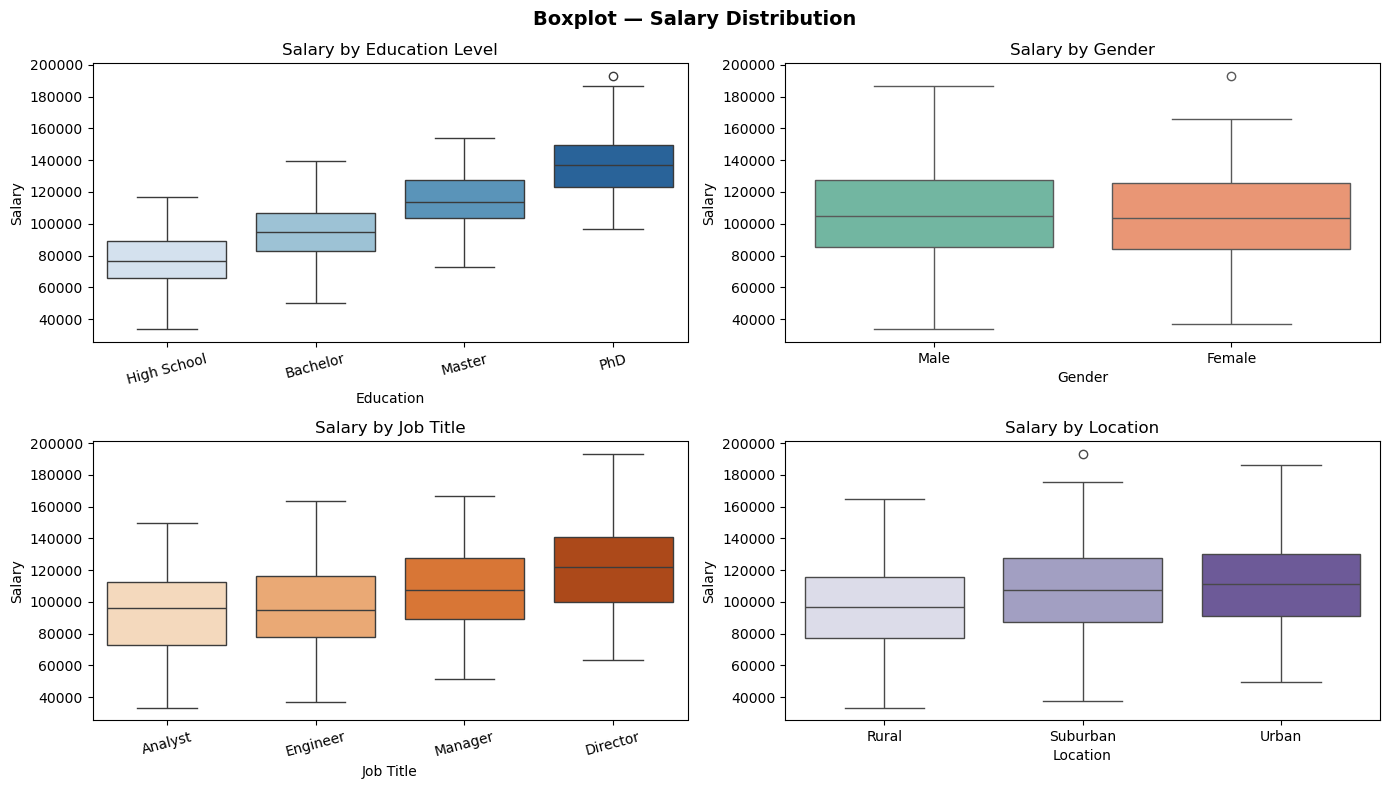

In [60]:
#salary vs gender 
#box-plot 
# salary vs edu
import seaborn as sns
plt.figure(figsize = (14,8))
plt.subplot(2,2,1)
df_orig = pd.read_csv('salary_prediction_data.csv')
sns.boxplot(x='Education', y='Salary', data=df_orig,
            order=['High School', 'Bachelor', 'Master', 'PhD'],
            palette='Blues')
plt.title('Salary by Education Level')
plt.xlabel('Education')
plt.ylabel('Salary')
plt.xticks(rotation=15)

plt.subplot(2,2,2)
sns.boxplot(x='Gender', y='Salary', data=df_orig, palette='Set2')
plt.title('Salary by Gender')
plt.xlabel('Gender')
plt.ylabel('Salary')

# job title 
plt.subplot(2, 2, 3)
sns.boxplot(x='Job_Title', y='Salary', data=df_orig,
            order=['Analyst', 'Engineer', 'Manager', 'Director'],
            palette='Oranges')
plt.title('Salary by Job Title')
plt.xlabel('Job Title')
plt.ylabel('Salary')
plt.xticks(rotation=15)

#location 
plt.subplot(2, 2, 4)
sns.boxplot(x='Location', y='Salary', data=df_orig,
            order=['Rural', 'Suburban', 'Urban'],
            palette='Purples')
plt.title('Salary by Location')
plt.xlabel('Location')
plt.ylabel('Salary')


plt.suptitle('Boxplot — Salary Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()


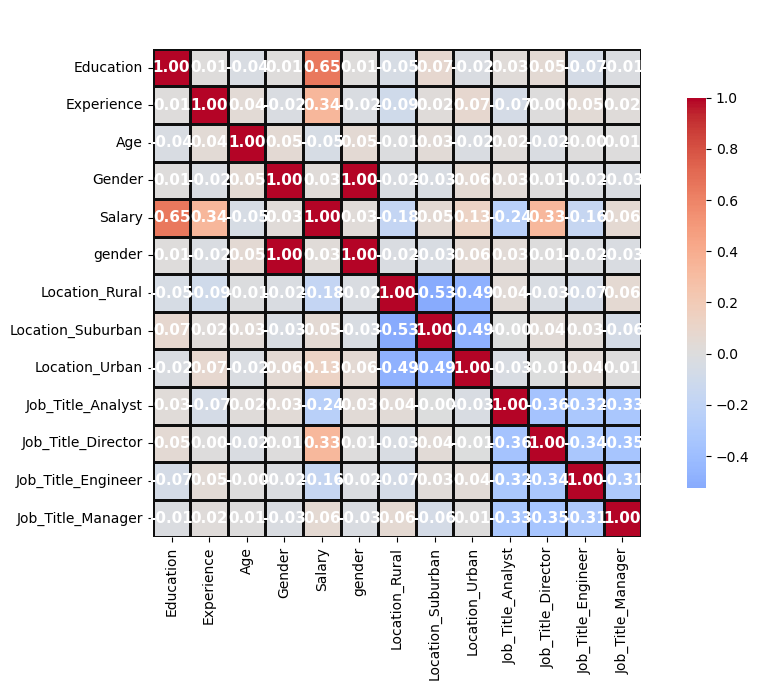

In [74]:
#corr heatmap 
df_encoded = df.copy()
fig , ax = plt.subplots(figsize = (10,7))


sns.heatmap(df_encoded.corr(),
           annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.8, linecolor='#0f0f0f',
            annot_kws={'size': 11, 'weight': 'bold', 'color': 'white'},
            ax=ax, square=True, cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap', fontsize=16,
             fontweight='bold', color='white', pad=15)

plt.tight_layout()
plt.show()




In [79]:
from sklearn.model_selection import train_test_split
# x and y 
X = df.drop('Salary', axis = 1)
y = df['Salary']


X_train , X_test , y_train , y_test = train_test_split(
    X , y , test_size = 0.2 , random_state = 42
)



In [84]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

#1.linear regresion 
lr = LinearRegression()
lr.fit(X_train , y_train)

#Decision Tree
dt = DecisionTreeRegressor(random_state= 42)
dt.fit(X_train , y_train)

#random forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 4. Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)



,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [92]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    'Linear Regression'  : lr,
    'Decision Tree'      : dt,
    'Random Forest'      : rf,
    'Gradient Boosting'  : gb
}

print(f"{'Model':<22} {'MAE':>8} {'RMSE':>10} {'R2 Score':>10}")
print("-" * 60)


for name , model in models.items():
    y_pred = model.predict(X_test)
    mae    = mean_absolute_error(y_test, y_pred)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    r2     = r2_score(y_test, y_pred)
    print(f"{name:<22} {mae:>8.2f} {rmse:>10.2f} {r2:>10.4f} ")

   

Model                       MAE       RMSE   R2 Score
------------------------------------------------------------
Linear Regression      13533.34   16360.14     0.6722 
Decision Tree          11627.46   14441.80     0.7446 
Random Forest           9319.09   11429.38     0.8400 
Gradient Boosting       8677.28   10776.58     0.8578 


In [97]:
print(X_train.columns.tolist())

['Education', 'Experience', 'Age', 'Gender', 'gender', 'Location_Rural', 'Location_Suburban', 'Location_Urban', 'Job_Title_Analyst', 'Job_Title_Director', 'Job_Title_Engineer', 'Job_Title_Manager']


In [ ]:
new_employee = {
 
    'Education'           : 2,
    'Experience'          : 5,
    'Age'                 : 28,
    'Gender'              : 1,    
    'gender'              : 1,    

  
    'Location_Rural'      : 0,
    'Location_Suburban'   : 0,
    'Location_Urban'      : 1,    


    'Job_Title_Analyst'   : 0,
    'Job_Title_Director'  : 0,
    'Job_Title_Engineer'  : 1,    
    'Job_Title_Manager'   : 0,
}

new_df = pd.DataFrame([new_employee])

# Predict
print("=" * 45)
print("   Salary Prediction — New Employee")
print("=" * 45)
for name, model in models.items():
    pred = model.predict(new_df)[0]
    print(f"{name:<22} : {pred:.2f}")


   Salary Prediction — New Employee
Linear Regression      : 102069.22
Decision Tree          : 98065.51
Random Forest          : 104513.24
Gradient Boosting      : 106213.96
